In [116]:
# importing necessary things
import torch
from models.model import SimSearchModel # importing simsearch model
from utils.augmentations import SimSearch_transform # transformation for image

# device for model running
device='cuda' if torch.cuda.is_available() else  'cpu'

model=SimSearchModel() # loading model
model.encoder.load_state_dict(torch.load("SimSearch_0_encoder.pth", map_location=device)) # laoding previously trained embneddings
# into model for better generalization
# this also ensures that, no need to train model everytime, 

model=model.encoder.to(device) # loading trained encoder of the model in device config
model.eval() # ready for model testing


SimSearchEncoder(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_s

In [117]:
# laoding the faiss index and image paths
import faiss
import pickle

index=faiss.read_index("SimSearch_0_image_index.faiss") # loading the faiss index
with open("SimSearch_0_image_paths.pkl", "rb") as f:
    image_paths=pickle.load(f) # loading the image paths



In [ ]:
# for the query image of SimSearch 
from PIL import Image
import torch

# every input images for similarity search needs to be transformed as training images
# get_embeddings ensures proper transformations before getting the actual output
def get_embeddings(img_path, model_encoder, transform, device):

    img=Image.open(img_path).convert('RGB') # converting the input image into RGB format
    img_tensor = transform(img).unsqueeze(0).to(device) # img tensor into device

    with torch.no_grad():
        embd=model_encoder(img_tensor)
    embd=embd.cpu().numpy().astype("float32")
    return embd


In [119]:
# searching similar image
query_embd=get_embeddings(img_path="test_data/dog.jpg", model_encoder=model, transform=SimSearch_transform, device=device)
k=3 # number of results
distances, indices=index.search(query_embd,k) # indices: similar image ids, distances: similarity score



In [120]:
results = [image_paths[i] for i in indices[0]]
print(results)

['mammals\\dog\\dog_original_00000003.jpg_8d2e2988-4125-42c1-9ecc-6ca882bb6d6a.jpg', 'mammals\\horse\\horse_original_00000085.jpg_d05c96fe-ca82-4905-a69c-4e24786b3a5e.jpg', 'mammals\\goat\\00000046.jpg']


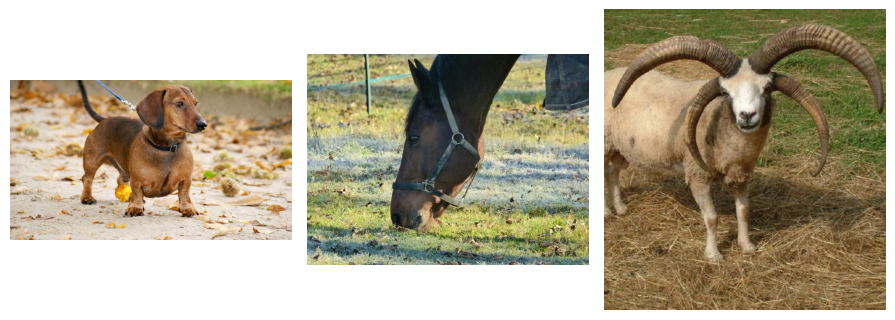

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import math

num_images = len(results)
cols = 5                     # images per row
rows = math.ceil(num_images / cols)

plt.figure(figsize=(15, 6))

for i, img_path in enumerate(results):
    img = Image.open(img_path)

    plt.subplot(rows, cols, i+1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()